In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
df = pd.read_csv(r"C:\Users\ullas gowda bu\OneDrive\Documents\Desktop\nlp project\text,category.csv")



In [42]:
df.head(5)

,text,category
0,India wins thrilling cricket series against Au...,Sports
1,Star football club signs young striker,Sports
2,Olympic athletes prepare for championship,Sports
3,Government announces new tax reforms,Politics
4,Parliament passes education bill,Politics


In [43]:
df.describe()

,text,category
count,15,15
unique,15,5
top,India wins thrilling cricket series against Au...,Sports
freq,1,3


In [44]:
df.columns

Index(['text', 'category'], dtype='object')

In [45]:
df.info

<bound method DataFrame.info of                                                  text       category
0   India wins thrilling cricket series against Au...         Sports
1              Star football club signs young striker         Sports
2           Olympic athletes prepare for championship         Sports
3                Government announces new tax reforms       Politics
4                    Parliament passes education bill       Politics
5         Election campaign begins across the country       Politics
6            New AI chatbot improves customer support     Technology
7   Cybersecurity experts warn about phishing attacks     Technology
8         Smartphone company launches flagship device     Technology
9         Blockbuster movie breaks box office records  Entertainment
10              Popular actor announces upcoming film  Entertainment
11          Music festival attracts thousands of fans  Entertainment
12                 Stock market closes at record high       Business
13

In [46]:
df.isnull().sum()

text        0
category    0
dtype: int64

In [47]:
print(df.columns.tolist())

['text', 'category']


In [48]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['text', 'category'], dtype='object')


In [35]:
print(df.columns)

Index(['| text                                                  | category      |'], dtype='object')


In [49]:
X = df["text"]
y = df["category"]

In [50]:
import re
import string

# Text cleaning function
def preprocess(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = text.strip()  # Remove extra spaces
    return text

# Apply preprocessing
df["text"] = df["text"].apply(preprocess)

print(df.head())

                                                text  category
0  india wins thrilling cricket series against au...    Sports
1             star football club signs young striker    Sports
2          olympic athletes prepare for championship    Sports
3               government announces new tax reforms  Politics
4                   parliament passes education bill  Politics


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Features and Target
X = df["text"]
y = df["category"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [52]:
# Predict categories
prediction = model.predict(X_test)

print("Predicted Categories:")
print(prediction)

# Predict a new article
new_article = ["India defeated Australia in the cricket world cup final"]

new_vector = vectorizer.transform(new_article)

result = model.predict(new_vector)

print("News:", new_article[0])
print("Predicted Category:", result[0])

Predicted Categories:
['Business' 'Business' 'Business']
News: India defeated Australia in the cricket world cup final
Predicted Category: Politics


In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, prediction)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, prediction))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, prediction))

Accuracy: 0.0

Classification Report
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00       0.0
Entertainment       0.00      0.00      0.00       2.0
       Sports       0.00      0.00      0.00       1.0

     accuracy                           0.00       3.0
    macro avg       0.00      0.00      0.00       3.0
 weighted avg       0.00      0.00      0.00       3.0


Confusion Matrix
[[0 0 0]
 [2 0 0]
 [1 0 0]]


C:\Users\ullas gowda bu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ullas gowda bu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ullas gowda bu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sk

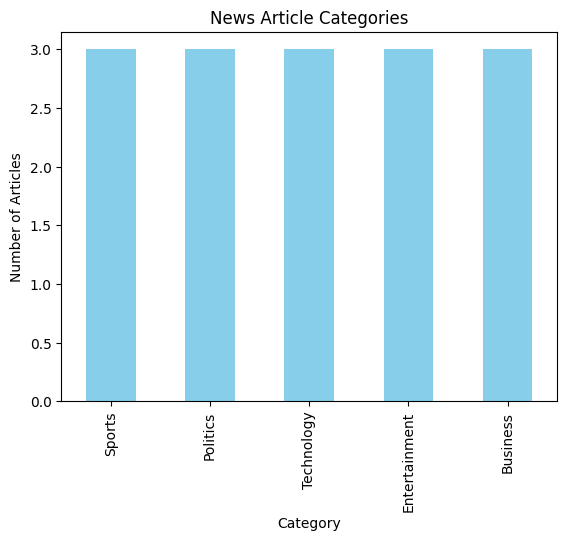

In [54]:
import matplotlib.pyplot as plt

# Count categories
df["category"].value_counts().plot(kind="bar", color="skyblue")

plt.title("News Article Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()

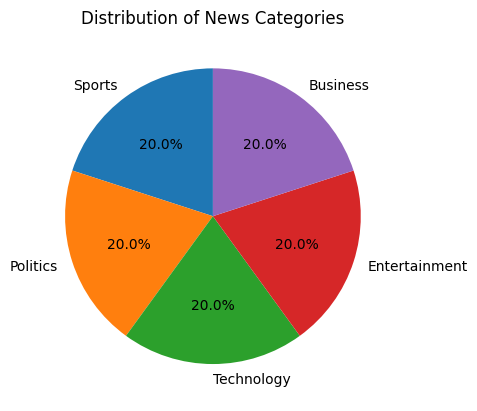

In [55]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of News Categories")
plt.ylabel("")
plt.show()

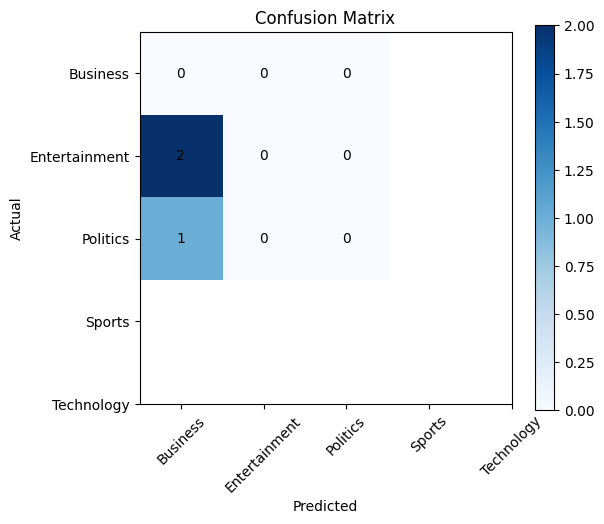

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(model.classes_)), model.classes_, rotation=45)
plt.yticks(range(len(model.classes_)), model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

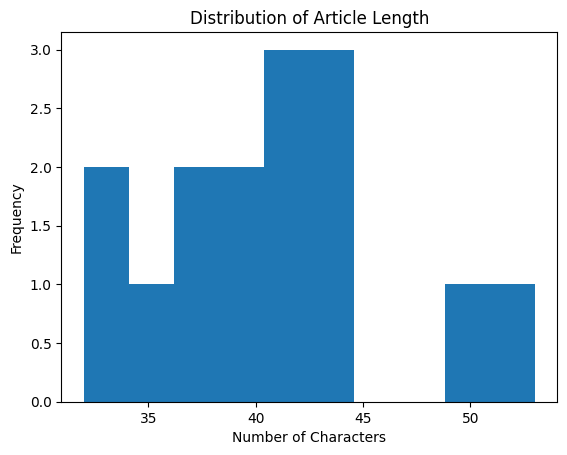

In [57]:
import matplotlib.pyplot as plt

df["Length"] = df["text"].apply(len)

plt.hist(df["Length"], bins=10)

plt.title("Distribution of Article Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()